# MITGCM Transect Time Scale Analysis Plotting

**Purpose**: Code for plotting the decorrelation time scale along a transect off the  coast of southern california. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import os
import cmocean.cm as cmo
from geopy.distance import geodesic
import matplotlib.gridspec as gridspec

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_freq_marker

Set plotting parameters

In [3]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_spec = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_grad = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load in mix layer depth and decorrelation scales along the transect

In [4]:
#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld  = PATH + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat                  = ds_mld['lat'] 
lon                  = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

#-------------------------------------------------------#
# Decorrelation scale Data
#-------------------------------------------------------#
filename_decor  = PATH + "/mitgcm_transect_temporal_scale_densityCalCOFI_line80_unc.npz"

# Load data 
ds_decor   = np.load(filename_decor, allow_pickle=True)

# Extract data variables
Lt_days       = ds_decor['Lt_days']         # Units: days
Lt_stdm_days  = ds_decor['Lt_stdm_days']    # Units: days
dist          = ds_decor['dist']            # Units: kilometers
depth         = ds_decor['depth']

#-------------------------------------------------------#
# Spectral Analysis Data
#-------------------------------------------------------#
filename_spec = PATH_spec + "/mitgcm_transect_potential_density_spectra.npz"

# Load data 
ds_spec   = np.load(filename_spec, allow_pickle=True)

# Extract data variables
FVE           = ds_spec['FVE']         
FVE_stdm      = ds_spec['FVE_unc'] 

#-------------------------------------------------------#
# Kinetic Energy Analysis Data
#-------------------------------------------------------#
filename_ke_tot = PATH_grad + "/mitgcm_transect_ke.npz"
filename_ke_bc = PATH_grad + "/mitgcm_transect_ke_baroclinic.npz"

# Load data 
ds_ke_tot   = np.load(filename_ke_tot, allow_pickle=True)
ds_ke_bc   = np.load(filename_ke_bc, allow_pickle=True)

# Extract data variables
FKE_tot       = ds_ke_tot['FKE']
FKE_bc        = ds_ke_bc['FKE']

#-------------------------------------------------------#
# Spatial Gradient Analysis Data
#-------------------------------------------------------#
filename_grad = PATH_grad + "/mitgcm_transect_spatial_gradients.npz"

# Load data 
ds_grad   = np.load(filename_grad, allow_pickle=True)

# Extract data variables
u_along_bar_mean       = ds_grad['u_along_bar_mean']
u_cross_bar_mean       = ds_grad['u_cross_bar_mean']
u_along_mean           = ds_grad['u_along_mean']
u_cross_mean           = ds_grad['u_cross_mean']
drho_dx_mean           = ds_grad['drho_dx_mean']      

#-------------------------------------------------------#
# Stratification Data
#-------------------------------------------------------#
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')

# Extract data variables
depth_mid = nc_tsd.variables['depth_mid'][:]
dist_nz      = nc_tsd.variables['DIST'][:]    
Nz  = nc_tsd.variables['NZ'][:] 

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
Nz = Nz[::-1,:]

#-------------------------------------------------------#
# Ocean Bottom Data
#-------------------------------------------------------#

# Set filename and read in netcdf file
filename = PATH_mld + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Mask fill values

In [5]:
u_along_mean = np.ma.masked_where(u_along_mean == 0, u_along_mean)
u_cross_mean = np.ma.masked_where(u_cross_mean == 0, u_cross_mean)
FKE_tot = np.ma.masked_where(FKE_tot == 0, FKE_tot)

Slice the data so that the analysis only considers offshore distances up to 123 degrees west

In [6]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat          = lat[idx_dist]
lon          = lon[idx_dist]
bottom_depth = bottom_depth[idx_dist]
mld          = mld[idx_dist,:]
mld_monthly_mean = mld_monthly_mean[idx_dist,:]

Compute cumulative distance along line 80.0 the mixed layer depth 

In [7]:
# Initialize array 
dist_mld = np.zeros(len(lon))

# Loop through stations 
for i in range(1,len(lon)): 

    # Define i and i + 1 points along transect
    pt1 = (lat[i-1], lon[i-1])
    pt2 = (lat[i],   lon[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

Set the locations of each cce mooring

In [8]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute the distance from the final CalCOFI station (closest to shore) and the shore

In [9]:
# Define points 
calcofi_station = (lat[0], lon[0])
shore           = (lat_shore,   lon_shore)

# Compute distance
dist_offset = geodesic(calcofi_station, shore).km

# Apply distance from shore correction
dist_cor     = dist + dist_offset
dist_mld_cor = dist_mld + dist_offset

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [10]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_stdm_days / (Lt_days - Lt_rho_spatial_mean)

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)

Compute the seasonally averaged mixed layer depth 

In [11]:
mld_mean = np.mean(mld_monthly_mean,axis=1)
mld_std  = np.std(mld_monthly_mean,ddof=1,axis=1)

Plot the map of the temporal decorrelation scale 

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_30254/107846066.py:13: UserWarning: linewidths is ignored by contourf
  ax.contourf(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_30254/107846066.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


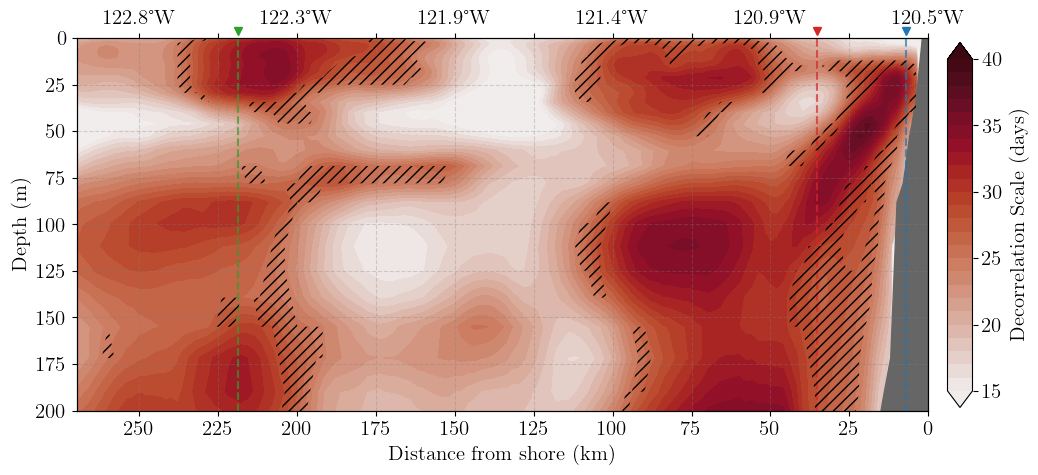

In [12]:
# Set plotting parameter
level = np.arange(15,40+1,1)

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist_cor,abs(depth),Lt_days.T, levels=level, cmap=cmo.amp, extend='both')

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    dist_cor,
    abs(depth),
    rho_mask.T,
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
)

# Plot seasonally averaged mixed layer depth
#ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
#ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Decorrelation Scale (days)')
cbar.set_ticks(np.arange(15,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig06.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Plot a figure of FVE and decorrelation time scale

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_23380/410197941.py:87: UserWarning: linewidths is ignored by contourf
  ax.contourf(


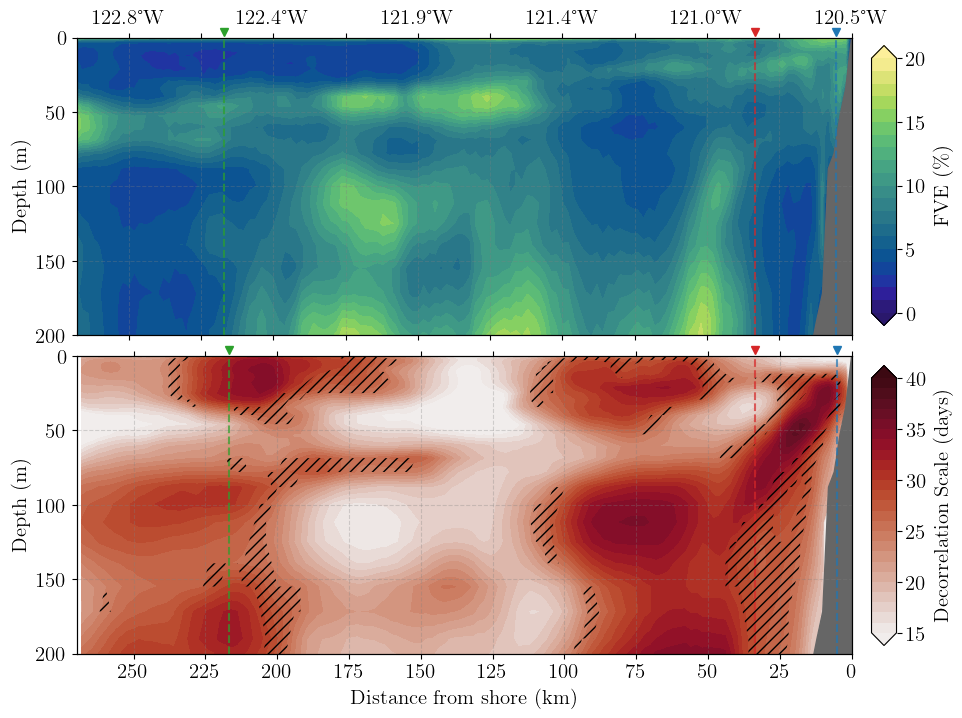

In [12]:
# Set plotting parameters
label_fve = r'FVE ($\%$)'
label_decor = 'Decorrelation Scale (days)'
levels_fve = np.arange(0,20+1,1)
levels_decor = np.arange(15,40+1,1)
cmap_fve = cmo.haline
cmap_decor = cmo.amp

# Create figure
fig, axes = plt.subplots(2,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FVE*100).T, levels=levels_fve, cmap=cmap_fve, extend='both')

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.52, 0.025, 0.35])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label_fve)
cbar.set_ticks(np.arange(0,20 + 5, 5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),Lt_days.T, levels=levels_decor, cmap=cmap_decor, extend='both')

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    dist_cor,
    abs(depth),
    rho_mask.T,
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
)


# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.12, 0.025, 0.35])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label(label_decor)
cbar.set_ticks(np.arange(15,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.07, wspace=0.1)
plt.show()

# Save with high quality
# figName = 'figS08.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Plot a scatter plot of FVE and decorrelation time scales and color code markers with distance from shore

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_23380/4124014171.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


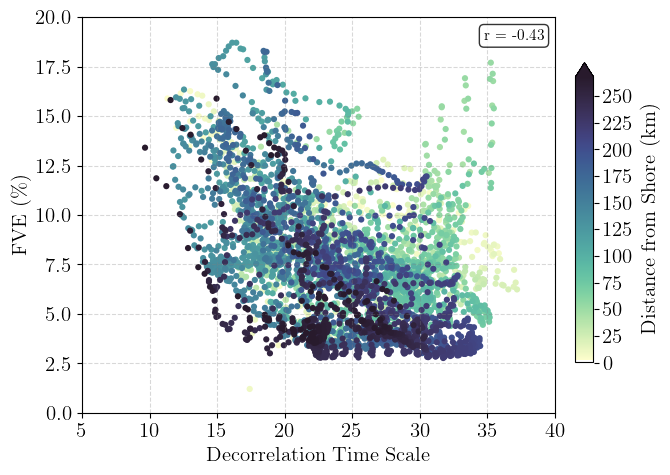

In [13]:
# Mask fill values (zeros) as NaNs
mask_fill = (FVE == 0) & (Lt_days == 0)
FVE = np.where(mask_fill, np.nan, FVE)
Lt_days = np.where(mask_fill, np.nan, Lt_days)

# Broadcast distance array
dist_2D = np.repeat(dist[:, None], FVE.shape[1], axis=1)

# Flatten arrays
FVE_flat = FVE.flatten()
Lt_flat = Lt_days.flatten()
dist_flat = dist_2D.flatten()

# Remove NaNs (important!)
mask = np.isfinite(FVE_flat) & np.isfinite(Lt_flat) & np.isfinite(dist_flat)
FVE_flat = FVE_flat[mask]
Lt_flat = Lt_flat[mask]
dist_flat = dist_flat[mask]

# Compute the Correlation Coefficient 
r = np.corrcoef(Lt_flat, FVE_flat)[0, 1]

# Convert FVE to percentage
FVE_flat = FVE_flat*100

# Create figure
fig, ax = plt.subplots(figsize=(6,5))

# Plot scatter plot
sc = plt.scatter(
    Lt_flat, 
    FVE_flat,
    c=dist_flat,
    cmap=cmo.deep,
    s=20,              
    marker='o',        
    edgecolor='none'
)

# Labels and formatting
ax.set_xlabel('Decorrelation Time Scale')
ax.set_ylabel(r'FVE ($\%$)')
ax.set_xlim(5,40)
ax.set_ylim(0,20)
ax.set_xticks(np.arange(5,40+5,5))
ax.set_yticks(np.arange(0,20+2.5,2.5))
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.98, 0.25, 0.03, 0.6])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cax, orientation='vertical', extend='max')
cbar.set_label('Distance from Shore (km)')
cbar.set_ticks(np.arange(0,250+25,25))

# Display the textbox with the correlation coefficient
ax.text(
    0.85, 0.97, 
    f"r = {r:.2f}",
    transform=ax.transAxes,   # use axis-relative coordinates
    fontsize=11,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.8,
        edgecolor='k'
    )
)

# Show figure
plt.tight_layout()
plt.show()

In [14]:
# Mask fill values (zeros) as NaNs
mask_fill = (FVE == 0) & (Lt_days == 0)

FVE = np.where(mask_fill, np.nan, FVE)
Lt_days = np.where(mask_fill, np.nan, Lt_days)

# Preallocate correlation array
r_dist = np.full(dist.size, np.nan)

# Compute correlation at each offshore distance
for i in range(dist.size):

    x = Lt_days[i, :]
    y = FVE[i, :]

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y)

    if np.sum(mask) > 1:
        r_dist[i] = np.corrcoef(x[mask], y[mask])[0, 1]

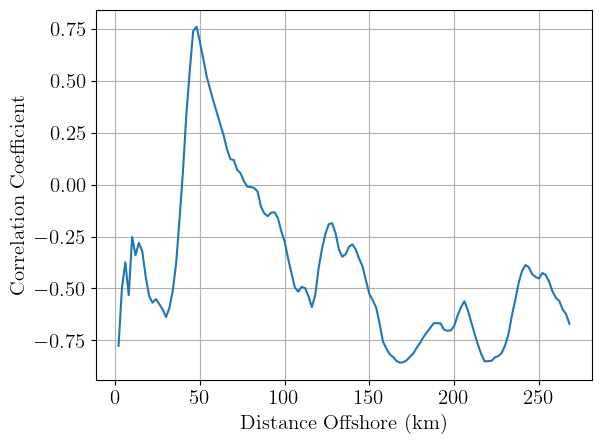

In [15]:
fig, ax = plt.subplots()

ax.plot(dist, r_dist)

ax.set_xlabel('Distance Offshore (km)')
ax.set_ylabel('Correlation Coefficient')
ax.grid(True)

Plot depth average velocity, total FKE, and baroclinic FKE  

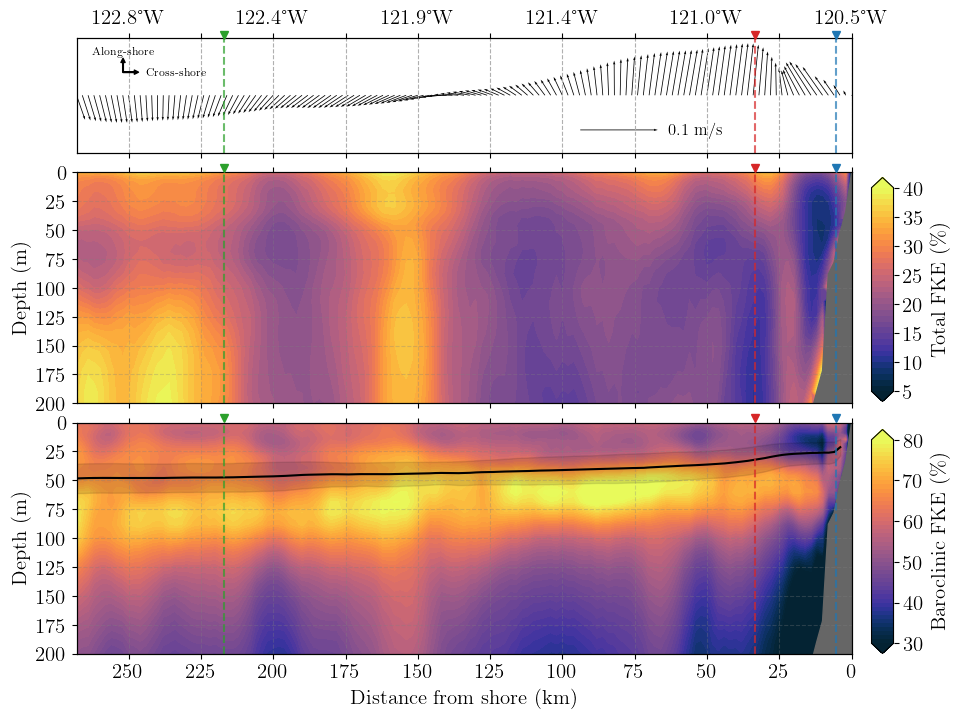

In [16]:
levels_tot = np.arange(5,40+1,1)
levels_bc = np.arange(30,80+1,1)

# Create figure
fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 2, 2]) 

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[0])

# Plot the velocity vectors
q = ax.quiver(dist, np.zeros_like(dist), u_cross_bar_mean, u_along_bar_mean, scale=1, width=0.001)

# Set axis attributes
ax.set_xlim(dist[0], dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks([])
#ax.set_xlabel('Distance from shore (km)')
ax.tick_params(top=True, bottom=True, left=False, right=False,
            direction='out', length=3.5)
ax.grid(True, linestyle='--')
ax.invert_xaxis()

# Add coordinate system arrows in top subplot
arrow_length_x,arrow_length_y = 0.02, 0.12  # adjust based on scale of your plot
x0, y0 = 0.06, 0.7    # location in axis coordinates (0–1)

# Add arrows using annotation in axis coordinates
ax.annotate('', xy=(x0 + arrow_length_x, y0), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0 + arrow_length_x + 0.01, y0, 'Cross-shore', transform=ax.transAxes,
        verticalalignment='center', fontsize=8)

ax.annotate('', xy=(x0, y0 + arrow_length_y), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0, y0 + arrow_length_y + 0.03, 'Along-shore', transform=ax.transAxes,
        horizontalalignment='center', fontsize=8)

# Set quiver legend
ax.quiverkey(q, X=0.75, Y=0.2, U=0.1, label='0.1 m/s', labelpos='E', coordinates='axes',fontproperties={'size': 12})

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[1])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FKE_tot*100).T, levels=levels_tot, cmap=cmo.thermal, extend='both')

# # Plot seasonally averaged mixed layer depth
# ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# # Plot standard deviation of mixed layer depth 
# ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.425, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical') 
cbar.set_label(r'Total FKE ($\%$)')
cbar.set_ticks(np.arange(5,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top and bottom x-axis ticklabels
ax.set_xticklabels([])
ax_top.set_xticklabels([])

#--- Subplot 2 ---# 
ax = fig.add_subplot(gs[2])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FKE_bc*100).T, levels=levels_bc, cmap=cmo.thermal, extend='both')

# Plot seasonally averaged mixed layer depth
ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.11, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Baroclinic FKE ($\%$)')
cbar.set_ticks(np.arange(30,80+10,10))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# Save with high quality
# figName = 'figS07.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


Plot the depth/time averaged velocity vectors, the time average velocity, the total FKE

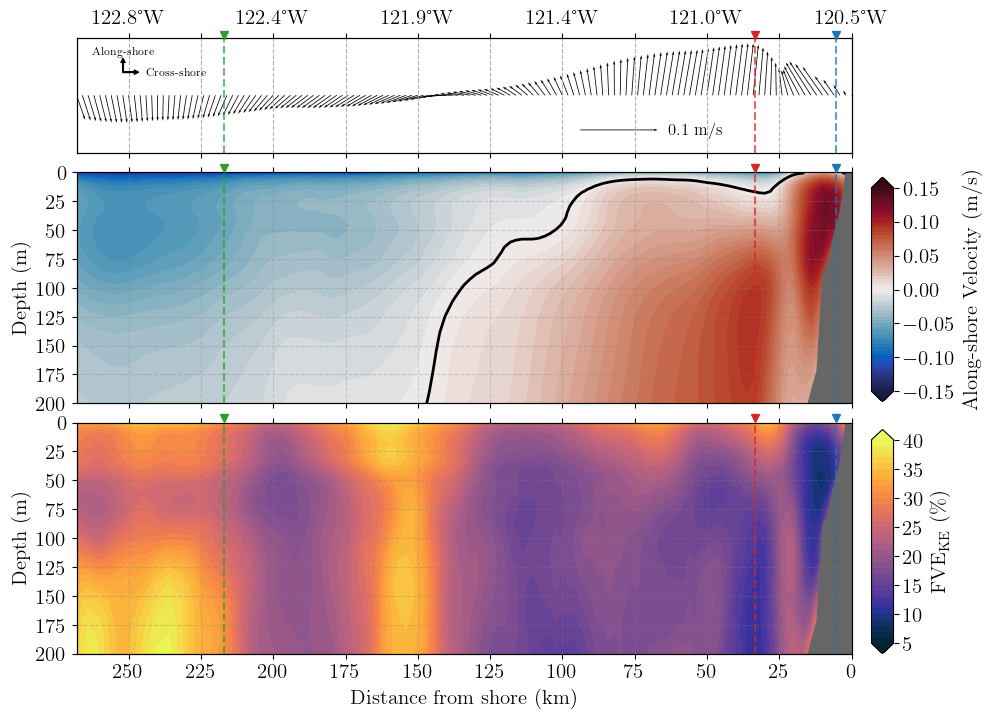

In [27]:
levels_tot = np.arange(5,40+1,1)
levels_mean = np.arange(-0.15, 0.15+0.005, 0.005)

# Create figure
fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 2, 2]) 

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[0])

# Plot the velocity vectors
q = ax.quiver(dist, np.zeros_like(dist), u_cross_bar_mean, u_along_bar_mean, scale=1, width=0.001)

# Set axis attributes
ax.set_xlim(dist[0], dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks([])
#ax.set_xlabel('Distance from shore (km)')
ax.tick_params(top=True, bottom=True, left=False, right=False,
            direction='out', length=3.5)
ax.grid(True, linestyle='--')
ax.invert_xaxis()

# Add coordinate system arrows in top subplot
arrow_length_x,arrow_length_y = 0.02, 0.12  # adjust based on scale of your plot
x0, y0 = 0.06, 0.7    # location in axis coordinates (0–1)

# Add arrows using annotation in axis coordinates
ax.annotate('', xy=(x0 + arrow_length_x, y0), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0 + arrow_length_x + 0.01, y0, 'Cross-shore', transform=ax.transAxes,
        verticalalignment='center', fontsize=8)

ax.annotate('', xy=(x0, y0 + arrow_length_y), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0, y0 + arrow_length_y + 0.03, 'Along-shore', transform=ax.transAxes,
        horizontalalignment='center', fontsize=8)

# Set quiver legend
ax.quiverkey(q, X=0.75, Y=0.2, U=0.1, label='0.1 m/s', labelpos='E', coordinates='axes',fontproperties={'size': 12})

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = fig.add_subplot(gs[1])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),u_along_mean.T, levels=levels_mean, cmap=cmo.balance, extend='both')
ax.contour(dist,abs(depth),u_along_mean.T, levels=[0], colors='k',linewidths=2)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.425, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical') 
cbar.set_label(r'Along-shore Velocity (m/s)')
cbar.set_ticks(np.arange(-0.15, 0.15+0.05, 0.05))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top and bottom x-axis ticklabels
ax.set_xticklabels([])
ax_top.set_xticklabels([])

#--- Subplot 3 ---# 
ax = fig.add_subplot(gs[2])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FKE_tot*100).T, levels=levels_tot, cmap=cmo.thermal, extend='both')

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.11, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'FVE$_{\rm{KE}}$ ($\%$)')
cbar.set_ticks(np.arange(5,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# Save with high quality
figName = 'figS08.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Plot decorrelation time scale with cross-shelf spatial density gradient contours over top

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_74671/3733108243.py:14: UserWarning: linewidths is ignored by contourf
  ax.contourf(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_74671/3733108243.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


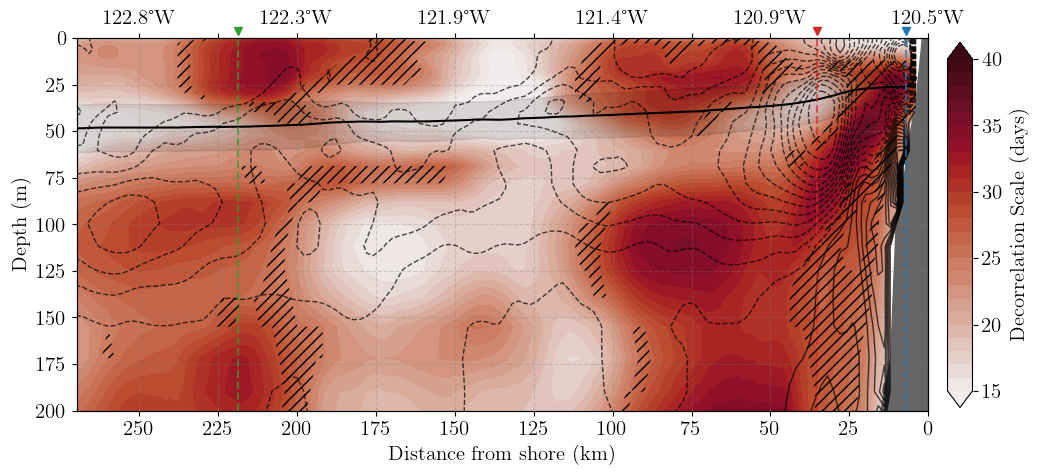

In [57]:
# Set plotting parameter
level = np.arange(15,40+1,1)
levels_dr = np.arange(-1.35*10**(-5), 1.35*10**(-5)+0.1*10**(-5), 0.1*10**(-5))

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist_cor,abs(depth),Lt_days.T, levels=level, cmap=cmo.amp, extend='both')

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    dist_cor,
    abs(depth),
    rho_mask.T,
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
)

# Overlay spatial gradients
cs = ax.contour(
    dist_cor,
    abs(depth),
    drho_dx_mean.T,
    levels=levels_dr,
    colors='k',        # black contours
    linewidths=1.0,
    alpha=0.7
)

# Plot seasonally averaged mixed layer depth
ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Decorrelation Scale (days)')
cbar.set_ticks(np.arange(15,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'fig05.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


Plot two profiles of stratification (one close to shore and one in the open ocean)

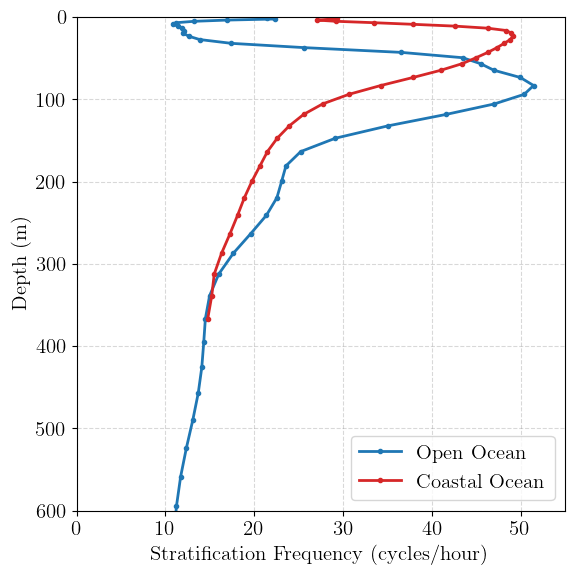

In [35]:
# Find the indices for specified distance from shore
nearshore = 18                              # Units: kilometers
offshore = 225                              # Units: kilometers
idx_n = np.abs(dist_nz - nearshore).argmin()
idx_o = np.abs(dist_nz - offshore).argmin()

# Create figure and axis 
fig, ax = plt.subplots(figsize=(6,6))

# Plot stratification profiles
ax.plot(Nz[idx_o,:],abs(depth_mid), '.-', color='tab:blue', lw=2,label='Open Ocean')
ax.plot(Nz[idx_n,:],abs(depth_mid), '.-', color='tab:red', lw=2,label='Coastal Ocean')

# Set figure attributes
ax.set_xlabel('Stratification Frequency (cycles/hour)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,55)
ax.set_ylim(0,600)
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')
ax.legend()

# Display 
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'supplementary_figs/figS61.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)


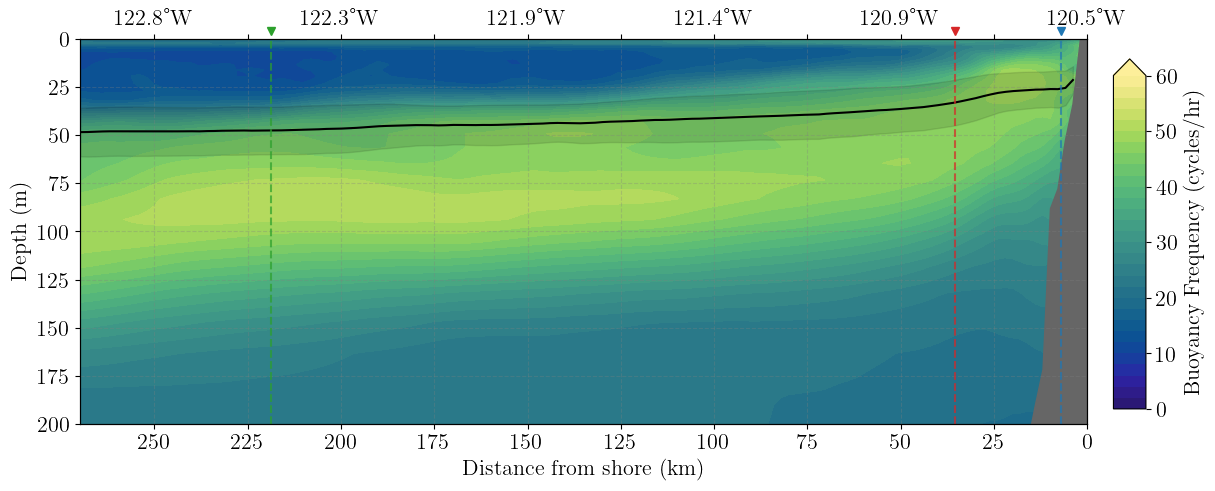

In [25]:
# Set plotting parameters
label = r'Buoyancy Frequency (cycles/hr)'
levels = np.arange(0,60+2,2)
cmap = cmo.haline

# Set plotting parameters 
fontsize = 16

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

# Create figure
fig, ax = plt.subplots(1,1,figsize=(13,5))

# Plot time-mean data
cf = ax.contourf(dist_nz,abs(depth_mid),Nz.T, levels=levels, cmap=cmap, extend='max')

# Plot seasonally averaged mixed layer depth
ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.14, 0.025, 0.7])   # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='max')
cbar.set_label(label)
cbar.set_ticks(np.arange(0,60+10,10))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Show figure 
plt.show()

# Save with high quality
figName = 'figS03.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)